# Vježbe 11 — Transfer Learning: Koristimo tuđi CNN
**Predmet:** Rudarenje podataka — I. godina — II ciklus — Softversko inženjerstvo  
**Asistent:** ass. mr. Narcisa Hadžajlić  
**Datum:** 4.5.2026.

---

## Šta smo do sada naučili
- **Vježbe 8:** MLP — forward pass, backpropagation, loss kriva
- **Vježbe 9:** Aktivacijske funkcije, overfitting, Dropout, Batch Normalization
- **Vježbe 10:** CNN — konvolucija, filteri, feature mape, MaxPooling

## Problem koji rješavamo danas

Na prošlim vježbama smo trenirali CNN od nule na MNIST-u — 70.000 slika, jednostavan problem, brzo treniranje.

U praksi situacija je drugačija:
- Imate **mali dataset** — npr. 500 fotografija vaše kompanije
- CNN koji radi od nule na 500 slika = **overfitting garantovan**
- Treniranje velikog CNN-a od nule = **dani potrošeni na GPU-u**, skup poduhvat

**Rješenje: Transfer Learning**

Neko je već odradio skupi dio posla! VGG16 i ResNet50 su trenirani na **ImageNetu — 1.2 milijuna slika, 1000 klasa**, sedmicama na skupim GPU-ima. Te mreže su naučile prepoznavati ivice, teksture, oblike, lica, objekte — gotovo sve vizualne obrasce koji postoje.

Mi uzimamo te naučene težine i **prilagođavamo ih našem problemu**. Umjesto da gradimo znanje od nule koristimo postojeće resurse.

### Plan za danas:
1. Intuicija — zašto transfer learning funkcioniše
2. Feature extraction — zamrzni pretreniranu mrežu, dodaj vlastiti classifier
3. Fine-tuning — odmrzni gornje layere i nauči ih na novom datasetu
4. Usporedba: CNN od nule vs. Transfer Learning
5. Zadatak na času — 4 boda

---
## 1. Zašto transfer learning funkcioniše?

CNN layeri uče hijerarhijski:

```
Rani layeri    →  ivice, linije, gradijenti boja       (univerzalno za SVE slike)
Srednji layeri →  teksture, obrasci, dijelovi oblika   (uglavnom univerzalno)
Kasni layeri   →  konkretni objekti, lica, automobili  (specifično za dataset)
```

Rani i srednji layeri su **univerzalni** — mreža naučena na psima i mačkama isto detektuje ivice kao mreža naučena na medicinskim snimcima. Samo kasni layeri su specifični za originalni problem.

### Dvije strategije:

**1. Feature Extraction (zamrzavanje)**
- Uzmi pretreniranu mrežu
- **Zamrzni sve težine** (`trainable = False`)
- Dodaj novi classification "head" (Dense layeri)
- Treniraj SAMO novi head
- Brzo, radi s malo podataka, ali ograničena prilagodba

**2. Fine-tuning (odmrzavanje)**
- Počni od feature extraction
- **Odmrzni gornje layere** pretreniranih mreža
- Treniraj s **veoma malim learning rateom** da ne uništiš naučene težine
- Sporije, treba više podataka, ali bolje rezultate

> **Pravilo:** Malo podataka + sličan domain → samo feature extraction. Više podataka ili drugačiji domain → fine-tuning.

---
## 2. Implementacija

In [ ]:
import tensorflow as tf
print(tf.__version__)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
print(tf.__version__)
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.datasets import cifar10

from sklearn.metrics import f1_score, classification_report, confusion_matrix

tf.get_logger().setLevel('ERROR')
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow: {tf.__version__}")
print("Sve uvezeno!")

2.21.0
TensorFlow: 2.21.0
Sve uvezeno!


### 2.1 Dataset — CIFAR-10

**CIFAR-10**: 60.000 slika u boji (32×32×3), 10 klasa: avion, automobil, ptica, mačka, jelen, pas, žaba, konj, brod, kamion. Puno teži od MNIST-a jer su slike u boji i sadržajno složenije.

**Važna napomena:** VGG16 i ResNet50 su trenirani na slikama **224×224**. Naše slike su 32×32: morat ćemo ih uvećati.

In [4]:
import kagglehub
import os
import numpy as np
from PIL import Image

# Skidanje dataseta
path = kagglehub.dataset_download("swaroopkml/cifar10-pngs-in-folders")
print("Path to dataset files:", path)

# Provjeri strukturu foldera
for root, dirs, files in os.walk(path):
    nivo = root.replace(path, '').count(os.sep)
    if nivo < 3:
        indent = ' ' * 2 * nivo
        print(f"{indent}{os.path.basename(root)}/")

100%|██████████| 140M/140M [00:08<00:00, 17.2MB/s] 

Extracting files...


Path to dataset files: C:\Users\Comp\.cache\kagglehub\datasets\swaroopkml\cifar10-pngs-in-folders\versions\1
1/
  cifar10/
    cifar10/


In [5]:
def ucitaj_iz_foldera(root_path, split='train'):
    """Učitava slike iz folder strukture: root/split/klasa/slika.png"""
    
    # Pronađi tačan path do train/test foldera
    split_path = None
    for root, dirs, files in os.walk(root_path):
        if os.path.basename(root) == split and any(os.path.isdir(
                os.path.join(root, d)) for d in dirs):
            split_path = root
            break
    
    if split_path is None:
        raise ValueError(f"Nije pronađen folder '{split}' u {root_path}")
    
    klase_lokalno = sorted(os.listdir(split_path))
    klase_lokalno = [k for k in klase_lokalno 
                     if os.path.isdir(os.path.join(split_path, k))]
    
    X, y = [], []
    for label_idx, klasa in enumerate(klase_lokalno):
        klasa_path = os.path.join(split_path, klasa)
        for img_file in os.listdir(klasa_path):
            if img_file.endswith('.png'):
                img = Image.open(os.path.join(klasa_path, img_file)).convert('RGB')
                X.append(np.array(img))
                y.append(label_idx)
    
    return np.array(X), np.array(y), klase_lokalno


print("Učitavam train slike...")
X_train_raw, y_train, klase_detected = ucitaj_iz_foldera(path, 'train')

print("Učitavam test slike...")
X_test_raw, y_test, _ = ucitaj_iz_foldera(path, 'test')

# Koristimo bosanska imena ako se poklapa redosljed
klase = ['avion', 'auto', 'ptica', 'mačka', 'jelen',
         'pas', 'žaba', 'konj', 'brod', 'kamion']

print(f"\nDetektovane klase: {klase_detected}")
print(f"Train: {X_train_raw.shape}")
print(f"Test:  {X_test_raw.shape}")
print(f"Vrijednosti piksela: min={X_train_raw.min()}, max={X_train_raw.max()}")

Učitavam train slike...
Učitavam test slike...

Detektovane klase: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train: (50000, 32, 32, 3)
Test:  (10000, 32, 32, 3)
Vrijednosti piksela: min=0, max=255


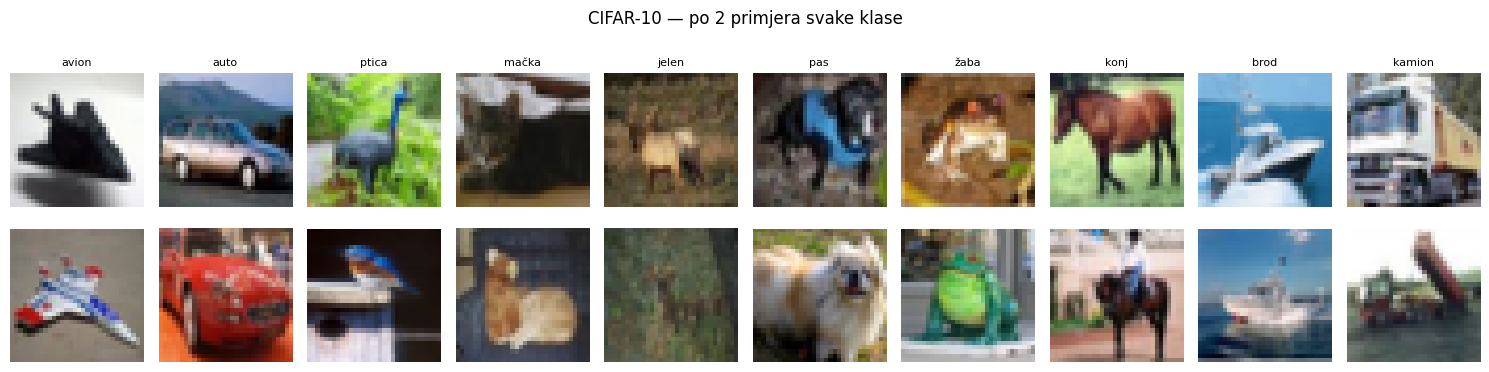

In [6]:
# Vizualizacija dataseta
fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i, klasa_ime in enumerate(klase):
    idx = np.where(y_train == i)[0][0]
    axes[0, i].imshow(X_train_raw[idx])
    axes[0, i].axis('off')
    axes[0, i].set_title(klasa_ime, fontsize=8)

    idx2 = np.where(y_train == i)[0][1]
    axes[1, i].imshow(X_train_raw[idx2])
    axes[1, i].axis('off')

plt.suptitle('CIFAR-10 — po 2 primjera svake klase', fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
# Koristimo podskup zbog brzine (transfer learning je efikasan i s malo podataka!)
# 5000 train + 1000 test po klasi = realan scenario s "malo" podataka
N_TRAIN = 5000
N_TEST  = 1000

idx_train = np.random.choice(len(X_train_raw), N_TRAIN, replace=False)
idx_test  = np.random.choice(len(X_test_raw),  N_TEST,  replace=False)

X_train_sub = X_train_raw[idx_train]
y_train_sub = y_train[idx_train]
X_test_sub  = X_test_raw[idx_test]
y_test_sub  = y_test[idx_test]

print(f"Podskup — Train: {X_train_sub.shape}, Test: {X_test_sub.shape}")
print("Simuliramo realan scenarij: mali dataset, trebamo transfer learning.")

Podskup — Train: (5000, 32, 32, 3), Test: (1000, 32, 32, 3)
Simuliramo realan scenarij: mali dataset, trebamo transfer learning.


### 2.2 Preprocessing za pretreniranu mrežu

VGG16 i ResNet50 imaju **vlastiti preprocessing**: specifična normalizacija piksela koja odgovara onome što su vidjeli tokom treninga na ImageNetu. Koristimo `preprocess_input` funkcije koje Keras nudi za svaki model.

Također, moramo **uvećati slike** sa 32×32 na 224×224 — minimalni input za ove mreže. Koristit ćemo `tf.image.resize`.

In [8]:
IMG_SIZE = 96  # Kompromis: 224×224 presporo na CPU, 96×96 dovoljno za demo
              # U produkciji koristite 224×224

def pripremi_slike(X, preprocess_fn, img_size=IMG_SIZE):
    """Resize i preprocess za pretreniranu mrežu."""
    X_float = X.astype('float32')
    # Resize: (N, 32, 32, 3) → (N, img_size, img_size, 3)
    X_resized = tf.image.resize(X_float, [img_size, img_size]).numpy()
    # Preprocess specifičan za mrežu (normalizacija po ImageNet statistikama)
    return preprocess_fn(X_resized)

print("Pripremam slike za VGG16...")
X_train_vgg = pripremi_slike(X_train_sub, vgg_preprocess)
X_test_vgg  = pripremi_slike(X_test_sub,  vgg_preprocess)

print("Pripremam slike za ResNet50...")
X_train_res = pripremi_slike(X_train_sub, resnet_preprocess)
X_test_res  = pripremi_slike(X_test_sub,  resnet_preprocess)

print(f"\nShape nakon preprocessinga: {X_train_vgg.shape}")
print(f"Vrijednosti VGG:    min={X_train_vgg.min():.1f}, max={X_train_vgg.max():.1f}")
print(f"Vrijednosti ResNet: min={X_train_res.min():.1f}, max={X_train_res.max():.1f}")
print("\nSvaka mreža ima svoju normalizaciju — ne koristimo /255 kao ranije!")

Pripremam slike za VGG16...
Pripremam slike za ResNet50...

Shape nakon preprocessinga: (5000, 96, 96, 3)
Vrijednosti VGG:    min=-123.7, max=151.1
Vrijednosti ResNet: min=-123.7, max=151.1

Svaka mreža ima svoju normalizaciju — ne koristimo /255 kao ranije!


### 2.3 Pregled VGG16 arhitekture

Pogledajmo šta je VGG16: koliko layera ima, koliko parametara, kako je organizovan.

In [10]:
# Učitaj VGG16 BEZ classification head-a (include_top=False)
# weights='imagenet' → preuzmi težine naučene na ImageNetu
vgg_base = VGG16(
    weights='imagenet',
    include_top=False,       # bez originalnih Dense layera (1000 klasa)
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

print("VGG16 arhitektura:")
print(f"  Broj layera:     {len(vgg_base.layers)}")
print(f"  Ukupno param.:   {vgg_base.count_params():,}")
print(f"  Output shape:    {vgg_base.output_shape}  ← feature vektor za svaku sliku")

# Prikaz layera
print("\nLayeri VGG16 base:")
for i, layer in enumerate(vgg_base.layers):
    try:
        output_shape = str(layer.output_shape)
    except AttributeError:
        output_shape = "n/a (input layer)"
    print(f"  [{i:2d}] {layer.name:25s}  output: {output_shape:30s}  params: {layer.count_params():,}")

VGG16 arhitektura:
  Broj layera:     19
  Ukupno param.:   14,714,688
  Output shape:    (None, 3, 3, 512)  ← feature vektor za svaku sliku

Layeri VGG16 base:
  [ 0] input_layer_1              output: n/a (input layer)               params: 0
  [ 1] block1_conv1               output: n/a (input layer)               params: 1,792
  [ 2] block1_conv2               output: n/a (input layer)               params: 36,928
  [ 3] block1_pool                output: n/a (input layer)               params: 0
  [ 4] block2_conv1               output: n/a (input layer)               params: 73,856
  [ 5] block2_conv2               output: n/a (input layer)               params: 147,584
  [ 6] block2_pool                output: n/a (input layer)               params: 0
  [ 7] block3_conv1               output: n/a (input layer)               params: 295,168
  [ 8] block3_conv2               output: n/a (input layer)               params: 590,080
  [ 9] block3_conv3               output: n/a (inpu

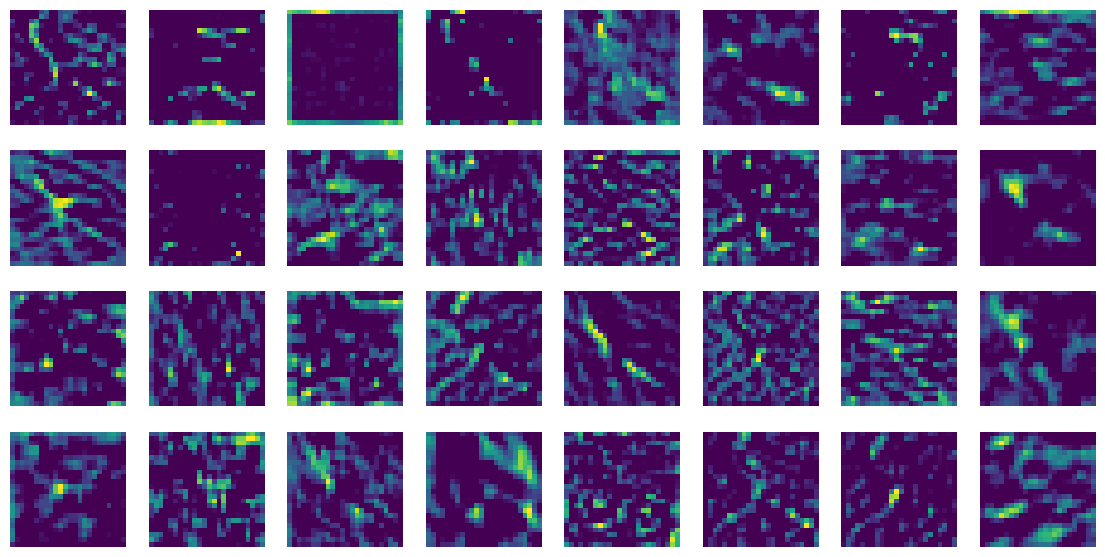

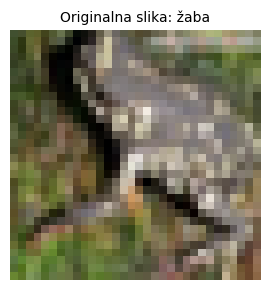

<Figure size 640x480 with 0 Axes>

VGG16 već detektuje složene obrasce — a nije ni vidio CIFAR tokom treninga!


In [11]:
# Vizualizacija: šta VGG16 "vidi" u našim CIFAR slikama PRIJE treninga
# (feature mape iz pretreniranog modela)

# Model koji vraća output posljednjeg Conv layera
feat_model = keras.Model(
    inputs=vgg_base.input,
    outputs=vgg_base.get_layer('block3_conv1').output
)

# Uzmimo jednu sliku
sample_idx  = 0
sample_img  = X_train_vgg[sample_idx:sample_idx+1]
sample_klas = klase[y_train_sub[sample_idx]]

feature_maps = feat_model.predict(sample_img, verbose=0)

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    if i < feature_maps.shape[-1]:
        ax.imshow(feature_maps[0, :, :, i], cmap='viridis')
    ax.axis('off')

# Originalna slika
fig2, ax2 = plt.subplots(1, 1, figsize=(3, 3))
ax2.imshow(X_train_sub[sample_idx])
ax2.set_title(f'Originalna slika: {sample_klas}', fontsize=10)
ax2.axis('off')
plt.tight_layout()
plt.show()

plt.suptitle(f'VGG16 feature mape (block3_conv1) za: {sample_klas} — BEZ fine-tuninga', fontsize=10)
plt.tight_layout()
plt.show()

print("VGG16 već detektuje složene obrasce — a nije ni vidio CIFAR tokom treninga!")

### 2.4 Strategija 1 — Feature Extraction (zamrzavanje)

Zamrzavamo VGG16 i dodajemo vlastiti classifier.

In [12]:
def napravi_feature_extractor(base_model, n_klasa=10):
    """Zamrzni base, dodaj novi classification head."""

    # ZAMRZNI sve težine base modela
    base_model.trainable = False

    model = keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        # GlobalAveragePooling: uzima prosjek svake feature mape
        # Alternativa Flatten-u — manje parametara, manje overfittinga
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(n_klasa, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# Kreiramo novi VGG16 base (svježi, nepromijenjeni)
vgg_base_fe = VGG16(weights='imagenet', include_top=False,
                    input_shape=(IMG_SIZE, IMG_SIZE, 3))

model_fe = napravi_feature_extractor(vgg_base_fe)

# Broj trenabilnih parametara
ukupno    = model_fe.count_params()
trenabilni = sum([tf.size(w).numpy() for w in model_fe.trainable_weights])
zamrznuti  = ukupno - trenabilni

print(f"Ukupno parametara:     {ukupno:>12,}")
print(f"Trenabilni (naši):     {trenabilni:>12,}  ← samo ovo učimo")
print(f"Zamrznuti (VGG16):     {zamrznuti:>12,}  ← ovo ne diramo")
print(f"\nTreniramo samo {trenabilni/ukupno*100:.1f}% parametara — ogromna ušteda!")

Ukupno parametara:       14,848,586
Trenabilni (naši):          133,898  ← samo ovo učimo
Zamrznuti (VGG16):       14,714,688  ← ovo ne diramo

Trenamo samo 0.9% parametara — ogromna ušteda!


In [13]:
print("Feature Extraction trening...")

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=4, restore_best_weights=True
)

historija_fe = model_fe.fit(
    X_train_vgg, y_train_sub,
    epochs=15,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

y_pred_fe = np.argmax(model_fe.predict(X_test_vgg, verbose=0), axis=1)
f1_fe     = f1_score(y_test_sub, y_pred_fe, average='weighted')

print(f"\nFeature Extraction — F1: {f1_fe:.4f}")

Feature Extraction trening...
Epoch 1/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 75s 549ms/step - accuracy: 0.4991 - loss: 2.7904 - val_accuracy: 0.7013 - val_loss: 0.9076
Epoch 2/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 64s 485ms/step - accuracy: 0.6833 - loss: 0.9946 - val_accuracy: 0.7333 - val_loss: 0.7792
Epoch 3/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 69s 519ms/step - accuracy: 0.7572 - loss: 0.7187 - val_accuracy: 0.7680 - val_loss: 0.7318
Epoch 4/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 67s 502ms/step - accuracy: 0.8075 - loss: 0.5749 - val_accuracy: 0.7947 - val_loss: 0.6890
Epoch 5/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 65s 488ms/step - accuracy: 0.8346 - loss: 0.4858 - val_accuracy: 0.7920 - val_loss: 0.7081
Epoch 6/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 66s 496ms/step - accuracy: 0.8633 - loss: 0.4017 - val_accuracy: 0.7920 - val_loss: 0.6943
Epoch 7/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 64s 481ms/step - accuracy: 0.8744 - loss: 0.3417 - val_accuracy: 0.8027 - val_loss: 0.6831
Epoch 8/15
133/133 ━━━━━━━━━━━━━━━━━━━━ 64s 482ms/ste

### 2.5 Strategija 2 — Fine-tuning

Sad odmrznemo gornje layere VGG16 i nastavimo trening s **mnogo manjim learning rateom**.

> **Zašto manji learning rate?** Pretreniranu mrežu zamislite kao precizno podešen instrument. Ako koristite isti learning rate kao za trening od nule, uništit ćete naučene težine u prvim koracima. Mali LR = fine podešavanje, ne resetovanje.

In [15]:
# Odmrzni gornje layere VGG16 (od bloka 4 nadalje)
# Rani layeri ostaju zamrznuti — oni uče universalne obrasce koji su već savršeni

vgg_base_fe.trainable = True  # odmrzni sve

# Zamrzni samo rane layere (blokovi 1-3)
zamrzni_do = 'block4_conv1'  # sve prije ovog ostaje zamrznuto
trainable  = False
for layer in vgg_base_fe.layers:
    if layer.name == zamrzni_do:
        trainable = True
    layer.trainable = trainable

# Prebrojimo
zamrznuti_ft  = sum([not l.trainable for l in vgg_base_fe.layers])
trenabilni_ft = sum([l.trainable for l in vgg_base_fe.layers])
print(f"VGG16 layeri — zamrznuti: {zamrznuti_ft}, trenabilni: {trenabilni_ft}")

# Rekompajliraj s MNOGO manjim learning rateom
model_fe.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # 100× manji LR!
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"\nFine-tuning learning rate: 1e-5 (bio: 1e-3 za feature extraction)")
print("Nastavljamo od gdje smo stali — ne treniramo od nule!")

VGG16 layeri — zamrznuti: 11, trenabilni: 8

Fine-tuning learning rate: 1e-5 (bio: 1e-3 za feature extraction)
Nastavljamo od gdje smo stali — ne treniramo od nule!


In [16]:
print("Fine-tuning trening...")

historija_ft = model_fe.fit(
    X_train_vgg, y_train_sub,
    epochs=10,
    batch_size=32,
    validation_split=0.15,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=4, restore_best_weights=True
    )],
    verbose=1
)

y_pred_ft = np.argmax(model_fe.predict(X_test_vgg, verbose=0), axis=1)
f1_ft     = f1_score(y_test_sub, y_pred_ft, average='weighted')

print(f"\nFeature Extraction F1: {f1_fe:.4f}")
print(f"Fine-tuning F1:        {f1_ft:.4f}")
print(f"Poboljšanje:           {f1_ft - f1_fe:+.4f}")

Fine-tuning trening...
Epoch 1/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 128s 949ms/step - accuracy: 0.8920 - loss: 0.3130 - val_accuracy: 0.8200 - val_loss: 0.6457
Epoch 2/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 133s 1000ms/step - accuracy: 0.9318 - loss: 0.2099 - val_accuracy: 0.8400 - val_loss: 0.6025
Epoch 3/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.9504 - loss: 0.1513 - val_accuracy: 0.8413 - val_loss: 0.6044
Epoch 4/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.9487 - loss: 0.1421 - val_accuracy: 0.8400 - val_loss: 0.6238
Epoch 5/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.9628 - loss: 0.1024 - val_accuracy: 0.8413 - val_loss: 0.6117
Epoch 6/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 132s 996ms/step - accuracy: 0.9722 - loss: 0.0828 - val_accuracy: 0.8600 - val_loss: 0.6038

Feature Extraction F1: 0.7901
Fine-tuning F1:        0.8079
Poboljšanje:           +0.0178


### 2.6 CNN od nule — za usporedbu

Isti dataset, isti broj epoha — ali bez predznanja iz ImageNeta.

In [17]:
# Preprocessing za CNN od nule: samo normalizacija
X_train_norm = X_train_sub.astype('float32') / 255.0
X_test_norm  = X_test_sub.astype('float32')  / 255.0

# Resize na isti input size za fer usporedbu
X_train_norm = tf.image.resize(X_train_norm, [IMG_SIZE, IMG_SIZE]).numpy()
X_test_norm  = tf.image.resize(X_test_norm,  [IMG_SIZE, IMG_SIZE]).numpy()

cnn_od_nule = keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])
cnn_od_nule.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"CNN od nule — parametri: {cnn_od_nule.count_params():,}")
print("Treniranje...")

historija_cnn = cnn_od_nule.fit(
    X_train_norm, y_train_sub,
    epochs=20,
    batch_size=32,
    validation_split=0.15,
    callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=0
)

y_pred_cnn = np.argmax(cnn_od_nule.predict(X_test_norm, verbose=0), axis=1)
f1_cnn_nule = f1_score(y_test_sub, y_pred_cnn, average='weighted')
print(f"CNN od nule — F1: {f1_cnn_nule:.4f}")

CNN od nule — parametri: 128,842
Treniranje...
CNN od nule — F1: 0.4462


### 2.7 Finalna usporedba svih pristupa

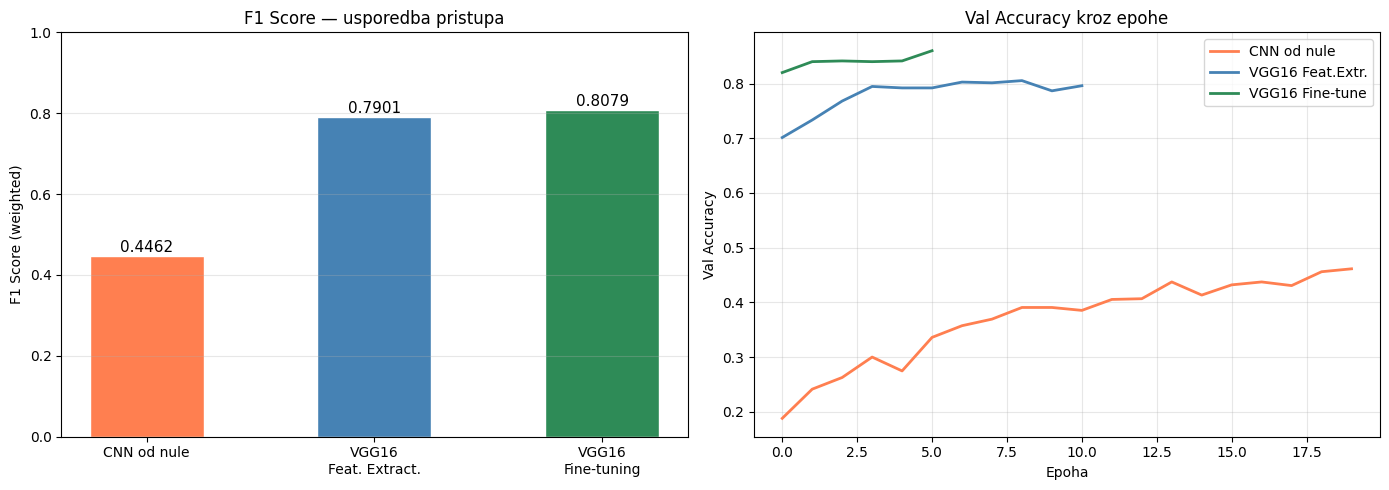


📊 Sažetak:
--------------------------------------------------
CNN od nule                F1: 0.4462
VGG16 Feat.Extr.           F1: 0.7901
VGG16 Fine-tuning          F1: 0.8079 ← BEST

Poboljšanje Transfer Learning vs CNN od nule: +0.3617


In [18]:
# Sažetak rezultata
rezultati = {
    'CNN od nule':          f1_cnn_nule,
    'VGG16\nFeat. Extract.': f1_fe,
    'VGG16\nFine-tuning':    f1_ft,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 usporedba
boje = ['coral', 'steelblue', 'seagreen']
bars = axes[0].bar(rezultati.keys(), rezultati.values(), color=boje, edgecolor='white', width=0.5)
axes[0].set_title('F1 Score — usporedba pristupa', fontsize=12)
axes[0].set_ylabel('F1 Score (weighted)')
axes[0].set_ylim(0, 1.0)
axes[0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, rezultati.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontsize=11)

# Kriva učenja — val accuracy
for hist, naziv, boja in [
    (historija_cnn, 'CNN od nule', 'coral'),
    (historija_fe,  'VGG16 Feat.Extr.', 'steelblue'),
    (historija_ft,  'VGG16 Fine-tune', 'seagreen'),
]:
    axes[1].plot(hist.history['val_accuracy'], label=naziv, color=boja, linewidth=2)

axes[1].set_title('Val Accuracy kroz epohe', fontsize=12)
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('Val Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Sažetak:")
print("-" * 50)
for naziv, f1 in zip(['CNN od nule', 'VGG16 Feat.Extr.', 'VGG16 Fine-tuning'], rezultati.values()):
    marker = " ← BEST" if f1 == max(rezultati.values()) else ""
    print(f"{naziv:25s}  F1: {f1:.4f}{marker}")

print(f"\nPoboljšanje Transfer Learning vs CNN od nule: {max(f1_fe, f1_ft) - f1_cnn_nule:+.4f}")

In [19]:
# Classification report za najbolji model
best_pred = y_pred_ft if f1_ft >= f1_fe else y_pred_fe
print("Classification Report — najbolji Transfer Learning model:")
print(classification_report(y_test_sub, best_pred, target_names=klase))

Classification Report — najbolji Transfer Learning model:
              precision    recall  f1-score   support

       avion       0.83      0.86      0.84        98
        auto       0.96      0.82      0.88        92
       ptica       0.82      0.68      0.75       117
       mačka       0.61      0.67      0.64        92
       jelen       0.67      0.76      0.71        92
         pas       0.83      0.76      0.79        96
        žaba       0.83      0.85      0.84       123
        konj       0.86      0.85      0.85        98
        brod       0.92      0.89      0.91       104
      kamion       0.78      0.94      0.85        88

    accuracy                           0.81      1000
   macro avg       0.81      0.81      0.81      1000
weighted avg       0.81      0.81      0.81      1000



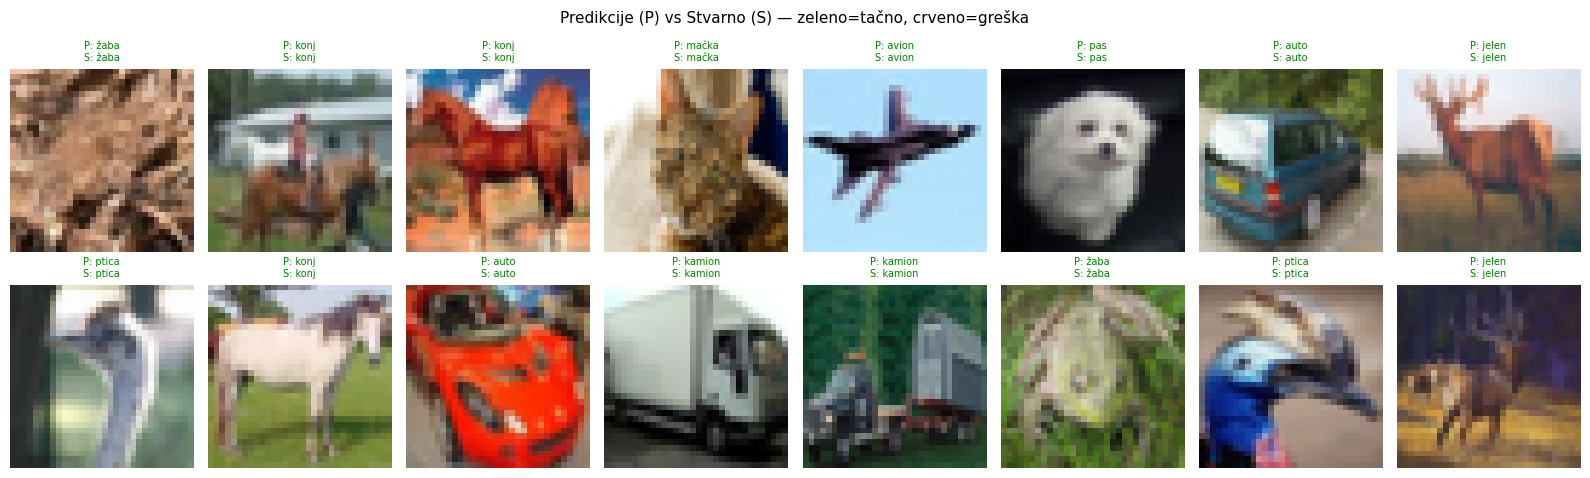

In [20]:
# Vizualizacija predikcija — šta model predviđa?
proba = model_fe.predict(X_test_vgg[:16], verbose=0)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i in range(16):
    ax = axes[i // 8, i % 8]
    ax.imshow(X_test_sub[i])
    predvideno = klase[np.argmax(proba[i])]
    stvarno    = klase[y_test_sub[i]]
    boja = 'green' if predvideno == stvarno else 'red'
    ax.set_title(f'P: {predvideno}\nS: {stvarno}', fontsize=7, color=boja)
    ax.axis('off')

plt.suptitle('Predikcije (P) vs Stvarno (S) — zeleno=tačno, crveno=greška', fontsize=11)
plt.tight_layout()
plt.show()

---
## 3. Šta smo naučili danas

| Koncept | Šta znači |
|---|---|
| **Transfer Learning** | Koristimo težine naučene na velikom datasetu za novi problem |
| **Feature Extraction** | Zamrzni pretreniranu mrežu, treniraj samo novi classifier |
| **Fine-tuning** | Odmrzni gornje layere, treniraj s malim LR-om |
| **`include_top=False`** | Uzmi mrežu bez originalnog classification head-a |
| **`trainable = False`** | Zamrzni layer — težine se ne mijenjaju tokom treninga |
| **`preprocess_input`** | Normalizacija specifična za svaku pretreniranu mrežu |
| **`GlobalAveragePooling2D`** | Prosjek feature mapa — alternativa Flatten-u, manje param. |
| **Mali LR za fine-tuning** | 1e-5 umjesto 1e-3 — ne uništavamo naučene težine |

---
## ZADATAK — 4 BODA

**Rok:** Predaja do 23:59 do 05.05.2026.

### Šta trebate uraditi:

1. **Pronađite image classification dataset** na [kaggle.com](https://kaggle.com):
   - **Različit od CIFAR-10!** Preporučeno: `Cats vs Dogs` (~1000 slika), `Flowers Recognition`, `Chest X-Ray Images`, `Garbage Classification`, `Pokemon Image Dataset`
   - Minimalno 2 klase, minimalno 200 slika ukupno
   - Ako je dataset u folderima (ImageFolder format), koristite `keras.utils.image_dataset_from_directory`

2. **Implementirajte Feature Extraction** s VGG16 ili ResNet50:
   - Učitajte pretreniranu mrežu s `include_top=False`
   - Zamrznite base (`trainable = False`)
   - Dodajte vlastiti classification head
   - Prikažite koliko % parametara trenirate

3. **Implementirajte Fine-tuning**:
   - Odmrznite gornje layere
   - Koristite learning rate ≤ 1e-5
   - Usporedite F1 prije i poslije fine-tuninga

4. **Napišite komentar** (markdown ćelija):
   - Koji dataset se izabrali i zašto?
   - Je li fine-tuning pomogao?
   - Šta mislite zašto transfer learning radi bolje od CNN-a od nule na malom datasetu?


### Bodovanje:
- **1 bod** — Feature extraction radi, F1 prikazan, zamrznuti parametri prikazani
- **1 bod** — Fine-tuning implementiran, usporedba s feature extraction, vlastiti dataset
- **1 bod** — Markdown komentar s razumijevanjem — posebno odgovor na treće pitanje
- **1 bod:** — Pokušajte s `ResNet50` umjesto VGG16 na istom datasetu. Koji daje bolji F1 i zašto mislite da je to tako?